### Seattle City Data

In [109]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

In [123]:
seattle = pd.read_csv("listings.csv.gz")
seattle.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [124]:
seattle = seattle.fillna(0)

In [125]:
seattle["price"] = (
    seattle["price"]
    .replace(r"[\$,]", "", regex=True)
    .astype(float)
)

In [134]:
features = [
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "minimum_nights",
    "availability_365",
    # "number_of_reviews",
    "price"
]

In [118]:
# seattle = seattle[seattle["price"] > 0]
# p99_seattle = seattle["price"].quantile(0.99)
# seattle = seattle[seattle["price"] <= p99]

In [135]:
# seattle = seattle[seattle['price'] > 0]
df_seattle = seattle[features]
df_seattle = df_seattle.fillna(0)
df_seattle

,accommodates,bedrooms,beds,bathrooms,minimum_nights,availability_365,price
0,1,1.0,1.0,1.0,30,177,99.0
1,2,1.0,2.0,3.0,2,327,71.0
2,4,1.0,0.0,0.0,30,0,0.0
3,8,3.0,3.0,2.0,30,178,311.0
4,4,1.0,2.0,1.0,2,221,88.0
...,...,...,...,...,...,...,...
6991,2,1.0,1.0,1.5,1,364,58.0
6992,2,1.0,1.0,1.5,1,364,58.0
6993,2,1.0,1.0,1.0,3,364,88.0
6994,2,1.0,1.0,1.0,30,365,132.0


In [112]:
# price = seattle["price"] 

# print("min price:", price.min())
# print("num <= 0:", (price <= 0).sum())
# print("num NaN:", price.isna().sum())
# print("top 5 largest:", price.sort_values(ascending=False).head())

y: price
x: room_type, minimum_night,  neighbourhood, neighbourhood_group

In [136]:
X = df_seattle
# y = lists["price"]
y = seattle['review_scores_rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [137]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [138]:
y_pred_seattle = rf.predict(X_test)

In [139]:
rmse = root_mean_squared_error(y_test, y_pred_seattle)
print("RMSE:", rmse)

RMSE: 1.3215677997999205


In [140]:
importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(15)

availability_365    0.283479
price               0.275562
minimum_nights      0.252465
accommodates        0.060385
bedrooms            0.048702
bathrooms           0.040209
beds                0.039197
dtype: float64

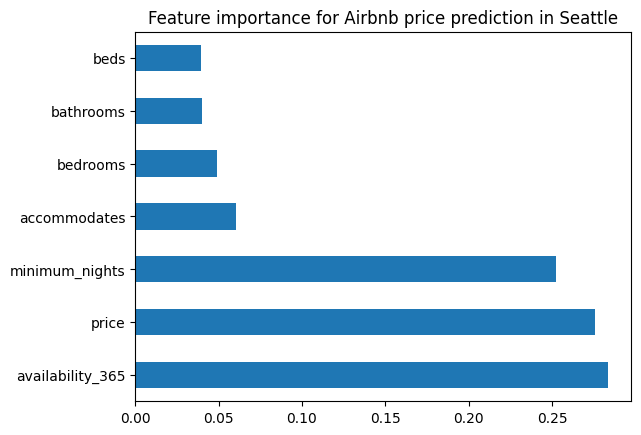

In [141]:
importance.head(10).plot(kind="barh")
plt.title("Feature importance for Airbnb price prediction in Seattle")
plt.show()

### San Francisco Data

In [142]:
sf = pd.read_csv("listings_1.csv.gz")

In [143]:
sf = sf.fillna(0)

In [144]:
sf["price"] = (
    sf["price"]
    .replace(r"[\$,]", "", regex=True)
    .astype(float)
)

In [145]:
df_sf = sf[features]
df_sf = df_sf.fillna(0)
df_sf

,accommodates,bedrooms,beds,bathrooms,minimum_nights,availability_365,price
0,3,1.0,2.0,1.0,2,228,0.0
1,4,2.0,2.0,2.0,30,365,0.0
2,1,3.0,1.0,4.0,32,362,0.0
3,2,1.0,1.0,1.5,9,339,0.0
4,2,1.0,1.0,1.5,1,365,0.0
...,...,...,...,...,...,...,...
7530,2,1.0,1.0,1.0,1,343,0.0
7531,1,1.0,1.0,1.0,7,356,0.0
7532,4,1.0,2.0,1.0,30,364,0.0
7533,1,1.0,1.0,1.0,3,364,0.0


In [146]:
X_sf = df_sf
# y = lists["price"]
y_sf = sf['review_scores_rating']

X_train_sf, X_test_sf, y_train_sf, y_test_sf = train_test_split(
    X_sf, y_sf, test_size=0.2, random_state=42
)

In [147]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_sf, y_train_sf)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [148]:
y_pred_sf = rf.predict(X_test_sf)

In [149]:
rmse = root_mean_squared_error(y_test_sf, y_pred_sf)
print("RMSE:", rmse)

RMSE: 1.9063020915587383


In [152]:
importance_sf = pd.Series(
    rf.feature_importances_,
    index=X_train_sf.columns
).sort_values(ascending=False)

importance_sf.head(15)

availability_365    0.432472
minimum_nights      0.169715
accommodates        0.131196
beds                0.098474
bedrooms            0.090572
bathrooms           0.077570
price               0.000000
dtype: float64

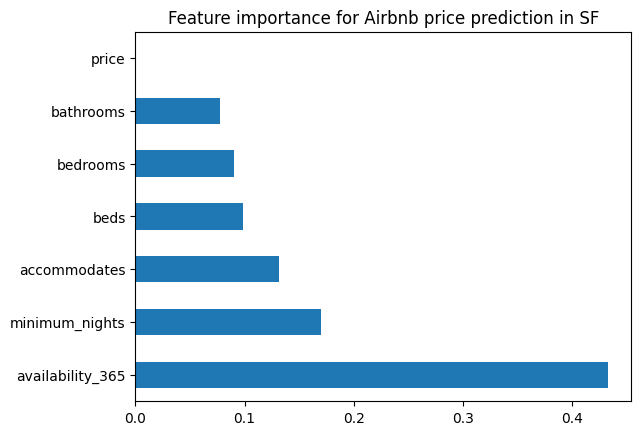

In [153]:
importance_sf.head(10).plot(kind="barh")
plt.title("Feature importance for Airbnb price prediction in SF")
plt.show()